# Theme Gallery

This gallery renders the same suite of example charts — the basic chart
types plus research-style figures — under each of the six predefined themes,
composed into a single grid per theme so the whole suite is visible at a
glance. The available themes are:

| Theme | Character |
| ----- | --------- |
| `THEME.DEFAULT` | Tableau-style categorical palette, open spines, soft grid. |
| `THEME.GREYSCALE` | Monochrome, print-friendly. |
| `THEME.INK` | Diversified YlGnBu palette with navy ink accents. |
| `THEME.MINIMAL` | Accent blue with deep grays, no spines, flat bars. |
| `THEME.MATERIAL` | Google palette, bottom spine only, light grid. |
| `THEME.HATCH` | Hatch cycle, black edges, dotted grid, value labels. |

Themes also carry *defaults for chart settings*: every theme shows a muted
y-grid unless a chart call sets `show_grid` itself, `MINIMAL`, `MATERIAL`, and
`HATCH` label bar values by default, and `HATCH` hatches bar series via
its hatch cycle — which is why the very same chart code below renders with
grids, value labels, and hatches that differ per theme. An explicit setting
always wins.

The small-multiples example is itself a `Grid`; grid figures nest inside
`Grid` (ADR 0006), so it takes the final cell of each theme's gallery grid.

In [1]:
import math
import random

import matplotlib.pyplot as plt

from datachart.charts import (
    BarChart,
    BoxPlot,
    ContourChart,
    Heatmap,
    Histogram,
    LineChart,
    ParallelCoords,
    PyramidChart,
    RadialChart,
    RaincloudPlot,
    ScatterChart,
    SwarmPlot,
    ViolinPlot,
)
from datachart.config import config
from datachart.constants import THEME, ORIENTATION
from datachart.utils import Grid, Panel
from datachart.utils.stats import kde1d, kde2d

random.seed(42)
FIGSIZE = (4.2, 3.0)


def ema(vals, alpha=0.35):
    out, acc = [], vals[0]
    for v in vals:
        acc = alpha * v + (1 - alpha) * acc
        out.append(acc)
    return out

The sample data shared by every theme suite is defined in a hidden cell.

In [2]:
BAR = [
    {"label": l, "y": y}
    for l, y in zip(
        ["Alpha", "Beta", "Gamma", "Delta", "Epsilon"], [54.0, 47.1, 62.3, 51.4, 43.8]
    )
]

CATS = ["Bench A", "Bench B", "Bench C", "Bench D"]
GROUPED = [
    [{"label": c, "y": y} for c, y in zip(CATS, [66.7, 58.6, 76.7, 83.2])],
    [{"label": c, "y": y} for c, y in zip(CATS, [65.4, 57.7, 77.8, 82.7])],
    [{"label": c, "y": y} for c, y in zip(CATS, [68.5, 53.4, 76.9, 85.9])],
]

LINES = [
    [
        {"x": x, "y": 40 + 18 * math.sin(x / 3.2) + x * k + random.uniform(-2, 2)}
        for x in range(0, 21)
    ]
    for k in (1.6, 0.9, 0.3)
]

SCATTER = [
    [{"x": random.gauss(mx, 1.4), "y": random.gauss(my, 1.2)} for _ in range(45)]
    for mx, my in ((3, 4), (6.5, 7), (9, 3.5))
]

HIST = [
    [{"x": random.gauss(50, 10)} for _ in range(400)],
    [{"x": random.gauss(68, 8)} for _ in range(400)],
]

HEAT = {
    "z": [
        [
            round(abs(math.sin(0.5 * i + 0.8 * j)) * (1 - 0.07 * abs(i - j)), 2)
            for j in range(6)
        ]
        for i in range(6)
    ],
}

# Pareto: model families, throughput (x, tok/s) vs performance (y, score)
PARETO_FAMILIES = {
    "Family A": [(12, 78.2), (28, 74.5), (55, 69.8), (140, 61.2)],
    "Family B": [(18, 76.9), (42, 72.1), (95, 66.4), (210, 58.9)],
    "Family C": [(8, 80.1), (35, 75.8), (75, 70.3), (180, 63.7)],
}
PARETO_SCATTER = [
    [{"x": x, "y": y} for x, y in pts] for pts in PARETO_FAMILIES.values()
]
all_points = [p for pts in PARETO_FAMILIES.values() for p in pts]
PARETO_FRONT = [
    {"x": x, "y": y}
    for x, y in sorted(all_points)
    if not any(ox >= x and oy > y for ox, oy in all_points if (ox, oy) != (x, y))
]

# Ablation: performance delta per component, positive and negative
ABLATION = [
    {"label": l, "y": y}
    for l, y in sorted(
        [
            ("+ data dedup", 0.121),
            ("+ RoPE scaling", 0.095),
            ("+ longer context", 0.062),
            ("+ distillation", 0.034),
            ("+ curriculum", 0.008),
            ("- dropout", -0.047),
            ("- weight decay", -0.128),
            ("- pretrain filter", -0.300),
        ],
        key=lambda t: t[1],
    )
]

# Training: noisy loss + smoothed trend (left), validation accuracy (right)
EPOCHS = list(range(1, 31))
TRAIN_LOSS = [
    2.5 * math.exp(-e / 8) + 0.4 + random.uniform(-0.08, 0.08) for e in EPOCHS
]
LOSS_TREND = ema(TRAIN_LOSS)
VAL_ACC = [
    50 + 38 * (1 - math.exp(-e / 10)) + random.uniform(-1.2, 1.2) for e in EPOCHS
]
VAL_TREND = ema(VAL_ACC)


# ROC curves: empirical step curves from simulated scores
def empirical_roc(sep, n=60):
    pos = sorted(random.gauss(sep, 1) for _ in range(n))
    neg = sorted(random.gauss(0, 1) for _ in range(n))
    scores = sorted(set(pos + neg), reverse=True)
    pts, auc_pairs = [{"x": 0.0, "y": 0.0}], 0
    for th in scores:
        tpr = sum(p >= th for p in pos) / n
        fpr = sum(g >= th for g in neg) / n
        pts.append({"x": fpr, "y": tpr})
    for p in pos:
        auc_pairs += sum(p > g for g in neg) + 0.5 * sum(p == g for g in neg)
    return pts, auc_pairs / (n * n)


ROC_CURVES, ROC_LABELS = [], []
for name, sep in zip("ABC", (2.2, 1.3, 0.5)):
    pts, auc = empirical_roc(sep)
    ROC_CURVES.append(pts)
    ROC_LABELS.append(f"Model {name} (AUC {auc:.2f})")
ROC_CHANCE = [{"x": 0, "y": 0}, {"x": 1, "y": 1}]

# Box plot: score distributions per release (long form)
BOX = [
    {"label": g, "value": random.gauss(mu, sd)}
    for g, mu, sd in (
        ("v1.0", 62, 6),
        ("v1.1", 68, 5),
        ("v2.0", 74, 7),
        ("v2.1", 71, 4),
    )
    for _ in range(60)
]

# Time series + EMA + forecast beyond the horizon
TS_X = list(range(0, 81))
TS_RAW = [
    20 + 0.12 * t + 4 * math.sin(t / 6) + random.uniform(-2.2, 2.2) for t in TS_X
]
TS_EMA = ema(TS_RAW, alpha=0.25)
FC_X = list(range(80, 101))
slope = (TS_EMA[-1] - TS_EMA[-13]) / 12
TS_FORECAST = [TS_EMA[-1] + slope * (t - 80) + 1.5 * math.sin(t / 6) for t in FC_X]
PEAK_DAY = max(range(41, 61), key=TS_EMA.__getitem__)


# Probability distributions (pdfs)
def npdf(x, mu, sd):
    return math.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * math.sqrt(2 * math.pi))


DIST_X = [i / 10 for i in range(-45, 66)]
DISTS = {
    "Normal(0, 1)": [{"x": x, "y": npdf(x, 0, 1)} for x in DIST_X],
    "Normal(2, 0.6)": [{"x": x, "y": npdf(x, 2, 0.6)} for x in DIST_X],
    "Skewed": [
        {
            "x": x,
            "y": 2
            * npdf(x, 0.5, 1.4)
            * (0.5 * (1 + math.erf(2.5 * (x - 0.5) / 1.4 / math.sqrt(2)))),
        }
        for x in DIST_X
    ],
    "Bimodal": [
        {"x": x, "y": 0.55 * npdf(x, -1.6, 0.7) + 0.45 * npdf(x, 3.4, 0.9)}
        for x in DIST_X
    ],
}

# Regression scatter: noisy linear data, fitted line + CI drawn by the chart
REG = [
    {"x": x, "y": 12 + 1.8 * x + random.gauss(0, 4.5)}
    for x in [random.uniform(0, 20) for _ in range(70)]
]

# Random walks pinned through waypoints (Brownian bridges)
WAYPOINTS = [(0, 0.0), (30, 8.0), (60, -4.0), (90, 10.0)]


def bridge(t0, v0, t1, v1, sigma=1.4):
    """One Brownian-bridge segment from (t0, v0) to (t1, v1)."""
    pts, v, n = [], v0, t1 - t0
    for i in range(n):
        remaining = n - i
        drift = (v1 - v) / remaining
        v += drift + sigma * random.gauss(0, 1) * math.sqrt((remaining - 1) / remaining)
        pts.append({"x": t0 + i + 1, "y": v if remaining > 1 else v1})
    return pts


WALKS = []
for _ in range(12):
    path = [{"x": WAYPOINTS[0][0], "y": WAYPOINTS[0][1]}]
    for (t0, v0), (t1, v1) in zip(WAYPOINTS, WAYPOINTS[1:]):
        path.extend(bridge(t0, path[-1]["y"], t1, v1))
    WALKS.append(path)
WAYPOINT_PTS = [{"x": t, "y": v} for t, v in WAYPOINTS]

# Parallel coords: hyperparameter-search trials, line color follows the score
PARCOORD = [
    {
        "lr": round(10 ** random.uniform(-4.3, -2.5), 5),
        "batch": random.choice([16, 32, 64, 128]),
        "layers": random.randint(2, 12),
        "dropout": round(random.uniform(0.0, 0.5), 2),
        "score": round(random.uniform(55, 92), 1),
    }
    for _ in range(45)
]

# Bars with error bars: benchmark mean +/- std over seeds
ERRBAR = [
    [{"label": c, "y": y, "yerr": e} for c, y, e in zip(CATS, ys, es)]
    for ys, es in (
        ([66.7, 58.6, 76.7, 83.2], [2.1, 3.4, 1.8, 1.2]),
        ([65.4, 57.7, 77.8, 82.7], [1.7, 2.9, 2.3, 1.5]),
    )
]

# Stacked bars: token-usage composition per release
STACKED = [
    [{"label": r, "y": y} for r, y in zip(["v1.0", "v1.1", "v2.0", "v2.1"], ys)]
    for ys in ([42, 38, 30, 24], [31, 33, 36, 38], [12, 15, 19, 24], [8, 9, 11, 13])
]

# Small multiples: daily counts per category (one big + grid of small)
SM_X = list(range(30))


def sm_series(peak, scale):
    return [
        {
            "x": t,
            "y": max(
                0.0,
                scale * math.exp(-((t - peak) ** 2) / 40)
                + random.uniform(0, scale * 0.25),
            ),
        }
        for t in SM_X
    ]


SM_CATS = {
    "English": (16, 300),
    "Spanish": (18, 160),
    "German": (12, 90),
    "French": (20, 70),
    "Slovenian": (15, 30),
    "Arabic": (17, 25),
}
SM_SERIES = {name: sm_series(p, sc) for name, (p, sc) in SM_CATS.items()}
SM_TOTAL = [{"x": t, "y": sum(s[t]["y"] for s in SM_SERIES.values())} for t in SM_X]

# Log-scale scaling law: loss vs compute across model sizes
SCALING = [
    [
        {
            "x": 10**c,
            "y": (3.2 * (10**c / 1e18) ** -0.05)
            * f
            * (1 + random.uniform(-0.01, 0.01)),
        }
        for c in [18 + 0.25 * i for i in range(13)]
    ]
    for f in (1.0, 0.93, 0.88)
]

# Radial profile: capability scores per axis for two model versions
RADIAL_AXES = ["Reasoning", "Coding", "Math", "Knowledge", "Safety", "Agentic"]
RADIAL = [
    [{"label": a, "y": y} for a, y in zip(RADIAL_AXES, ys)]
    for ys in ([72, 81, 64, 77, 85, 58], [83, 78, 76, 74, 88, 79])
]

PYR_AGE_BANDS = [f"{lo}-{lo + 2}" for lo in range(0, 90, 3)]
PYRAMID = [
    [
        {"label": b, "y": round(max(9.0 - abs(i - 11) * 0.55 + 1.6 * math.sin(i / 2.4), 1.2), 1)}
        for i, b in enumerate(PYR_AGE_BANDS)
    ],
    [
        {"label": b, "y": round(max(8.4 - abs(i - 14) * 0.48 + 1.4 * math.sin(i / 3.1 + 1.2), 1.0), 1)}
        for i, b in enumerate(PYR_AGE_BANDS)
    ],
]

# Loss landscape: the "peaks" surface sampled on a 90x90 grid
PEAKS_X = [-3 + 6 * i / 89 for i in range(90)]
PEAKS = {
    "x": PEAKS_X,
    "y": PEAKS_X,
    "z": [
        [
            3 * (1 - x) ** 2 * math.exp(-(x**2) - (y + 1) ** 2)
            - 10 * (x / 5 - x**3 - y**5) * math.exp(-(x**2) - y**2)
            - math.exp(-((x + 1) ** 2) - y**2) / 3
            for x in PEAKS_X
        ]
        for y in PEAKS_X
    ],
}


The whole suite is built by one function (in a hidden cell), so every theme
renders the exact same chart code — grids, value labels, and hatches come from the theme's own
defaults. `pair` supplies the two accent colors used where a chart styles
lines explicitly (trend/forecast/walk examples). Intermediate figures that
only exist to feed a `Panel` are closed as we go, so only the final grid is
displayed. The small-multiples `Grid` nests as the last gallery cell and rebuilds
its own layout there; the nested charts on the block's edges keep their
y-axes inline with the gallery column's axes.

In [3]:
def theme_suite(pair):
    """Build the twenty-nine-chart example suite under the current theme."""
    c1, c2 = pair
    figs = []

    # trends and comparisons (charts index order)

    figs.append(
        LineChart(
            LINES,
            title="Line",
            figsize=FIGSIZE,
            subtitle=["Run 1", "Run 2", "Run 3"],
            show_legend=True,
        )
    )

    figs.append(BarChart(BAR, title="Bar", figsize=FIGSIZE, value_format="%.1f"))

    figs.append(
        BarChart(
            GROUPED,
            title="Grouped bar",
            figsize=FIGSIZE,
            subtitle=["Model A", "Model B", "Model C"],
            show_values=False,
            show_legend=True,
        )
    )

    # ablation study: diverging horizontal bars
    figs.append(
        BarChart(
            ABLATION,
            title="Ablation: performance delta",
            orientation=ORIENTATION.HORIZONTAL,
            show_values=True,
            value_format="%.3f",
            xlabel="Δ score",
            show_grid="x",
            figsize=FIGSIZE,
            vlines={
                "x": 0,
                "style": {
                    "plot_vline_width": 1.0,
                    "plot_vline_style": "-",
                    "plot_vline_alpha": 1.0,
                },
            },
        )
    )

    figs.append(
        BarChart(
            ERRBAR,
            title="Benchmark scores (3 seeds)",
            subtitle=["Model A", "Model B"],
            show_yerr=True,
            show_values=False,
            show_legend=True,
            figsize=FIGSIZE,
        )
    )

    figs.append(
        BarChart(
            STACKED,
            title="Token usage by release",
            subtitle=["Reasoning", "Code", "Tool use", "Other"],
            bar_mode="stack",
            show_values=False,
            show_legend=True,
            ylabel="Share (%)",
            figsize=FIGSIZE,
        )
    )

    figs.append(
        PyramidChart(
            PYRAMID,
            title="Pyramid",
            figsize=FIGSIZE,
            subtitle=["Site A", "Site B"],
            show_legend=True,
            show_values=False,
            yticks=list(range(0, 30, 5)),
            yticklabels=[PYR_AGE_BANDS[i] for i in range(0, 30, 5)],
        )
    )

    figs.append(
        RadialChart(
            RADIAL,
            title="Radial",
            figsize=FIGSIZE,
            subtitle=["Model v1", "Model v2"],
            show_area=True,
            ymin=0,
            show_legend=True,
        )
    )

    # empirical ROC curves + chance diagonal
    figs.append(
        LineChart(
            ROC_CURVES + [ROC_CHANCE],
            subtitle=ROC_LABELS + ["Chance"],
            style=[{"plot_line_drawstyle": "steps-post"}] * len(ROC_CURVES)
            + [
                {
                    "plot_line_style": "--",
                    "plot_line_color": "#888888",
                    "plot_line_width": 1.2,
                }
            ],
            title="ROC curves",
            xlabel="False positive rate",
            ylabel="True positive rate",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )

    figs.append(
        LineChart(
            SCALING,
            subtitle=["1 epoch", "2 epochs", "4 epochs"],
            title="Scaling law",
            xlabel="Compute (FLOPs)",
            ylabel="Loss",
            scalex="log",
            scaley="log",
            show_legend=True,
            style=[{"plot_line_marker": "o"}] * 3,
            figsize=FIGSIZE,
        )
    )

    figs.append(
        LineChart(
            list(DISTS.values()),
            subtitle=list(DISTS.keys()),
            title="Probability distributions",
            xlabel="x",
            ylabel="Density",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )

    # text annotation: the theme's plot_text_* box, text, and connector
    figs.append(
        LineChart(
            [{"x": t, "y": v} for t, v in zip(TS_X, TS_EMA)],
            title="Annotated trend",
            xlabel="Day",
            ylabel="Value",
            figsize=FIGSIZE,
            texts=[
                {
                    "text": "cycle peak",
                    "x": 0.18,
                    "y": 0.88,
                    "coords": "axes",
                    "target": (PEAK_DAY, TS_EMA[PEAK_DAY]),
                },
                {
                    "text": "smoothed EMA",
                    "x": 0.62,
                    "y": 0.06,
                    "coords": "axes",
                    "style": {"plot_text_box_visible": False},
                },
            ],
        )
    )

    # distributions

    figs.append(
        Histogram(
            HIST,
            title="Histogram",
            figsize=FIGSIZE,
            subtitle=["Before", "After"],
            show_legend=True,
        )
    )

    # 1-D density: the binned distribution with its kernel density curve
    binned = Histogram(HIST[0], subtitle="Binned", show_density=True, figsize=FIGSIZE)
    curve = LineChart(
        kde1d([p["x"] for p in HIST[0]]),
        subtitle="Kernel density",
        show_area=True,
        figsize=FIGSIZE,
    )
    figs.append(
        Panel(
            [binned, curve],
            title="Density curve",
            ylabel_left="Density",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )
    plt.close(binned)
    plt.close(curve)

    figs.append(
        BoxPlot(
            BOX,
            title="Score distribution by release",
            ylabel="Score",
            show_outliers=True,
            figsize=FIGSIZE,
        )
    )

    figs.append(
        ViolinPlot(
            BOX,
            title="Score density by release",
            ylabel="Score",
            figsize=FIGSIZE,
        )
    )

    figs.append(
        RaincloudPlot(
            BOX,
            title="Score raincloud by release",
            ylabel="Score",
            figsize=FIGSIZE,
        )
    )

    # every observation on top of its summary box, points in the theme's swarm style
    boxes = BoxPlot(BOX, show_outliers=False, figsize=FIGSIZE)
    points = SwarmPlot(BOX, figsize=FIGSIZE)
    figs.append(
        Panel(
            [{"figure": boxes, "emphasis": "background"}, points],
            title="Score spread by release",
            ylabel_left="Score",
            figsize=FIGSIZE,
        )
    )
    plt.close(boxes)
    plt.close(points)

    # relationships

    figs.append(
        ScatterChart(
            SCATTER,
            title="Scatter",
            figsize=FIGSIZE,
            subtitle=["C1", "C2", "C3"],
            show_legend=True,
        )
    )

    figs.append(
        ScatterChart(
            REG,
            title="Model fit with confidence interval",
            xlabel="Input",
            ylabel="Prediction",
            show_regression=True,
            show_ci=True,
            figsize=FIGSIZE,
        )
    )

    figs.append(
        Heatmap(HEAT, title="Heatmap", figsize=FIGSIZE, show_heatmap_values=True)
    )

    figs.append(
        ContourChart(
            PEAKS,
            title="Filled contour",
            figsize=FIGSIZE,
            filled=True,
        )
    )

    figs.append(
        ContourChart(
            PEAKS,
            title="Contour lines",
            figsize=FIGSIZE,
            show_labels=True,
            valfmt="{x:.0f}",
        )
    )

    # 2-D density: the scatter clusters as a kernel density surface
    figs.append(
        ContourChart(
            kde2d(
                [p["x"] for pts in SCATTER for p in pts],
                [p["y"] for pts in SCATTER for p in pts],
                gridsize=60,
            ),
            title="Density contour",
            figsize=FIGSIZE,
            filled=True,
        )
    )

    # parallel coordinates: numeric hue colors lines along the theme ramp
    figs.append(
        ParallelCoords(
            PARCOORD,
            title="Hyperparameter search",
            dimensions=["lr", "batch", "layers", "dropout", "score"],
            hue="score",
            figsize=FIGSIZE,
        )
    )

    # composition: panels

    # pareto front: scatter families + frontier line
    families = ScatterChart(
        PARETO_SCATTER, subtitle=list(PARETO_FAMILIES.keys()), figsize=FIGSIZE
    )
    front = LineChart(
        PARETO_FRONT,
        subtitle="Pareto front",
        style={"plot_line_style": "--", "plot_line_color": "#555555"},
        figsize=FIGSIZE,
    )
    figs.append(
        Panel(
            [families, front],
            title="Model performance vs throughput",
            xlabel="Throughput (tok/s)",
            ylabel_left="Score",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )
    plt.close(families)
    plt.close(front)

    # training loss + validation performance on twin axes
    loss = LineChart(
        [{"x": e, "y": v} for e, v in zip(EPOCHS, TRAIN_LOSS)],
        subtitle="Train loss",
        style={"plot_line_alpha": 0.3, "plot_line_color": c1},
        figsize=FIGSIZE,
    )
    loss_trend = LineChart(
        [{"x": e, "y": v} for e, v in zip(EPOCHS, LOSS_TREND)],
        subtitle="Loss trend",
        style={"plot_line_style": "--", "plot_line_color": c1},
        figsize=FIGSIZE,
    )
    val = LineChart(
        [{"x": e, "y": v} for e, v in zip(EPOCHS, VAL_ACC)],
        subtitle="Val accuracy",
        style={"plot_line_alpha": 0.3, "plot_line_color": c2},
        figsize=FIGSIZE,
    )
    val_trend = LineChart(
        [{"x": e, "y": v} for e, v in zip(EPOCHS, VAL_TREND)],
        subtitle="Val trend",
        style={"plot_line_style": "--", "plot_line_color": c2},
        figsize=FIGSIZE,
    )
    figs.append(
        Panel(
            [
                {"figure": loss, "y_axis": "left"},
                {"figure": loss_trend, "y_axis": "left"},
                {"figure": val, "y_axis": "right"},
                {"figure": val_trend, "y_axis": "right"},
            ],
            title="Training loss vs validation performance",
            xlabel="Epoch",
            ylabel_left="Loss",
            ylabel_right="Accuracy (%)",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )
    for fig in (loss, loss_trend, val, val_trend):
        plt.close(fig)

    # time series + EMA + forecast horizon
    raw = LineChart(
        [{"x": t, "y": v} for t, v in zip(TS_X, TS_RAW)],
        subtitle="Observed",
        style={"plot_line_alpha": 0.3, "plot_line_color": c1},
        figsize=FIGSIZE,
    )
    smoothed = LineChart(
        [{"x": t, "y": v} for t, v in zip(TS_X, TS_EMA)],
        subtitle="EMA",
        style={"plot_line_color": c1},
        figsize=FIGSIZE,
    )
    forecast = LineChart(
        [{"x": t, "y": v} for t, v in zip(FC_X, TS_FORECAST)],
        subtitle="Forecast",
        style={"plot_line_style": "--", "plot_line_color": c2},
        vlines={"x": 80, "style": {"plot_vline_style": ":"}},
        figsize=FIGSIZE,
    )
    figs.append(
        Panel(
            [raw, smoothed, forecast],
            title="Time series forecast",
            xlabel="Day",
            ylabel_left="Value",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )
    for fig in (raw, smoothed, forecast):
        plt.close(fig)

    # random walks through pinned waypoints
    walks = LineChart(
        WALKS,
        subtitle=[None] * len(WALKS),
        style=[
            {"plot_line_alpha": 0.3, "plot_line_width": 1.0, "plot_line_color": c1}
        ]
        * len(WALKS),
        figsize=FIGSIZE,
    )
    pins = ScatterChart(
        WAYPOINT_PTS,
        subtitle="Waypoints",
        style={"plot_scatter_color": "#1F1F1F", "plot_scatter_size": 45},
        figsize=FIGSIZE,
    )
    figs.append(
        Panel(
            [walks, {"figure": pins, "y_axis": "left", "z_order": 5}],
            title="Random walks through waypoints",
            xlabel="Step",
            ylabel_left="Value",
            figsize=FIGSIZE,
        )
    )
    plt.close(walks)
    plt.close(pins)

    return figs


def small_multiples():
    """The small-multiples example — a Grid figure that nests as one cell."""
    total = LineChart(SM_TOTAL, title="All languages", figsize=(4.6, 1.8))
    smalls = [
        LineChart(pts, title=cat, figsize=(2.0, 1.4)) for cat, pts in SM_SERIES.items()
    ]
    # one axis label per axis for the whole grid
    grid = Grid(
        [[total], smalls[:3], smalls[3:]],
        title="Article distribution by language",
        xlabel="Day",
        ylabel="Articles",
        figsize=(4.2, 3.4),
    )
    for fig in [total] + smalls:
        plt.close(fig)
    return grid


def render_gallery(theme, pair):
    config.set_theme(theme)
    figs = theme_suite(pair) + [small_multiples()]
    grid = Grid(figs, max_cols=3)
    for fig in figs:
        plt.close(fig)
    return grid


## Default

The modernized default: Tableau-style palette, white bar edges, open spines, soft y-grid from the theme default.

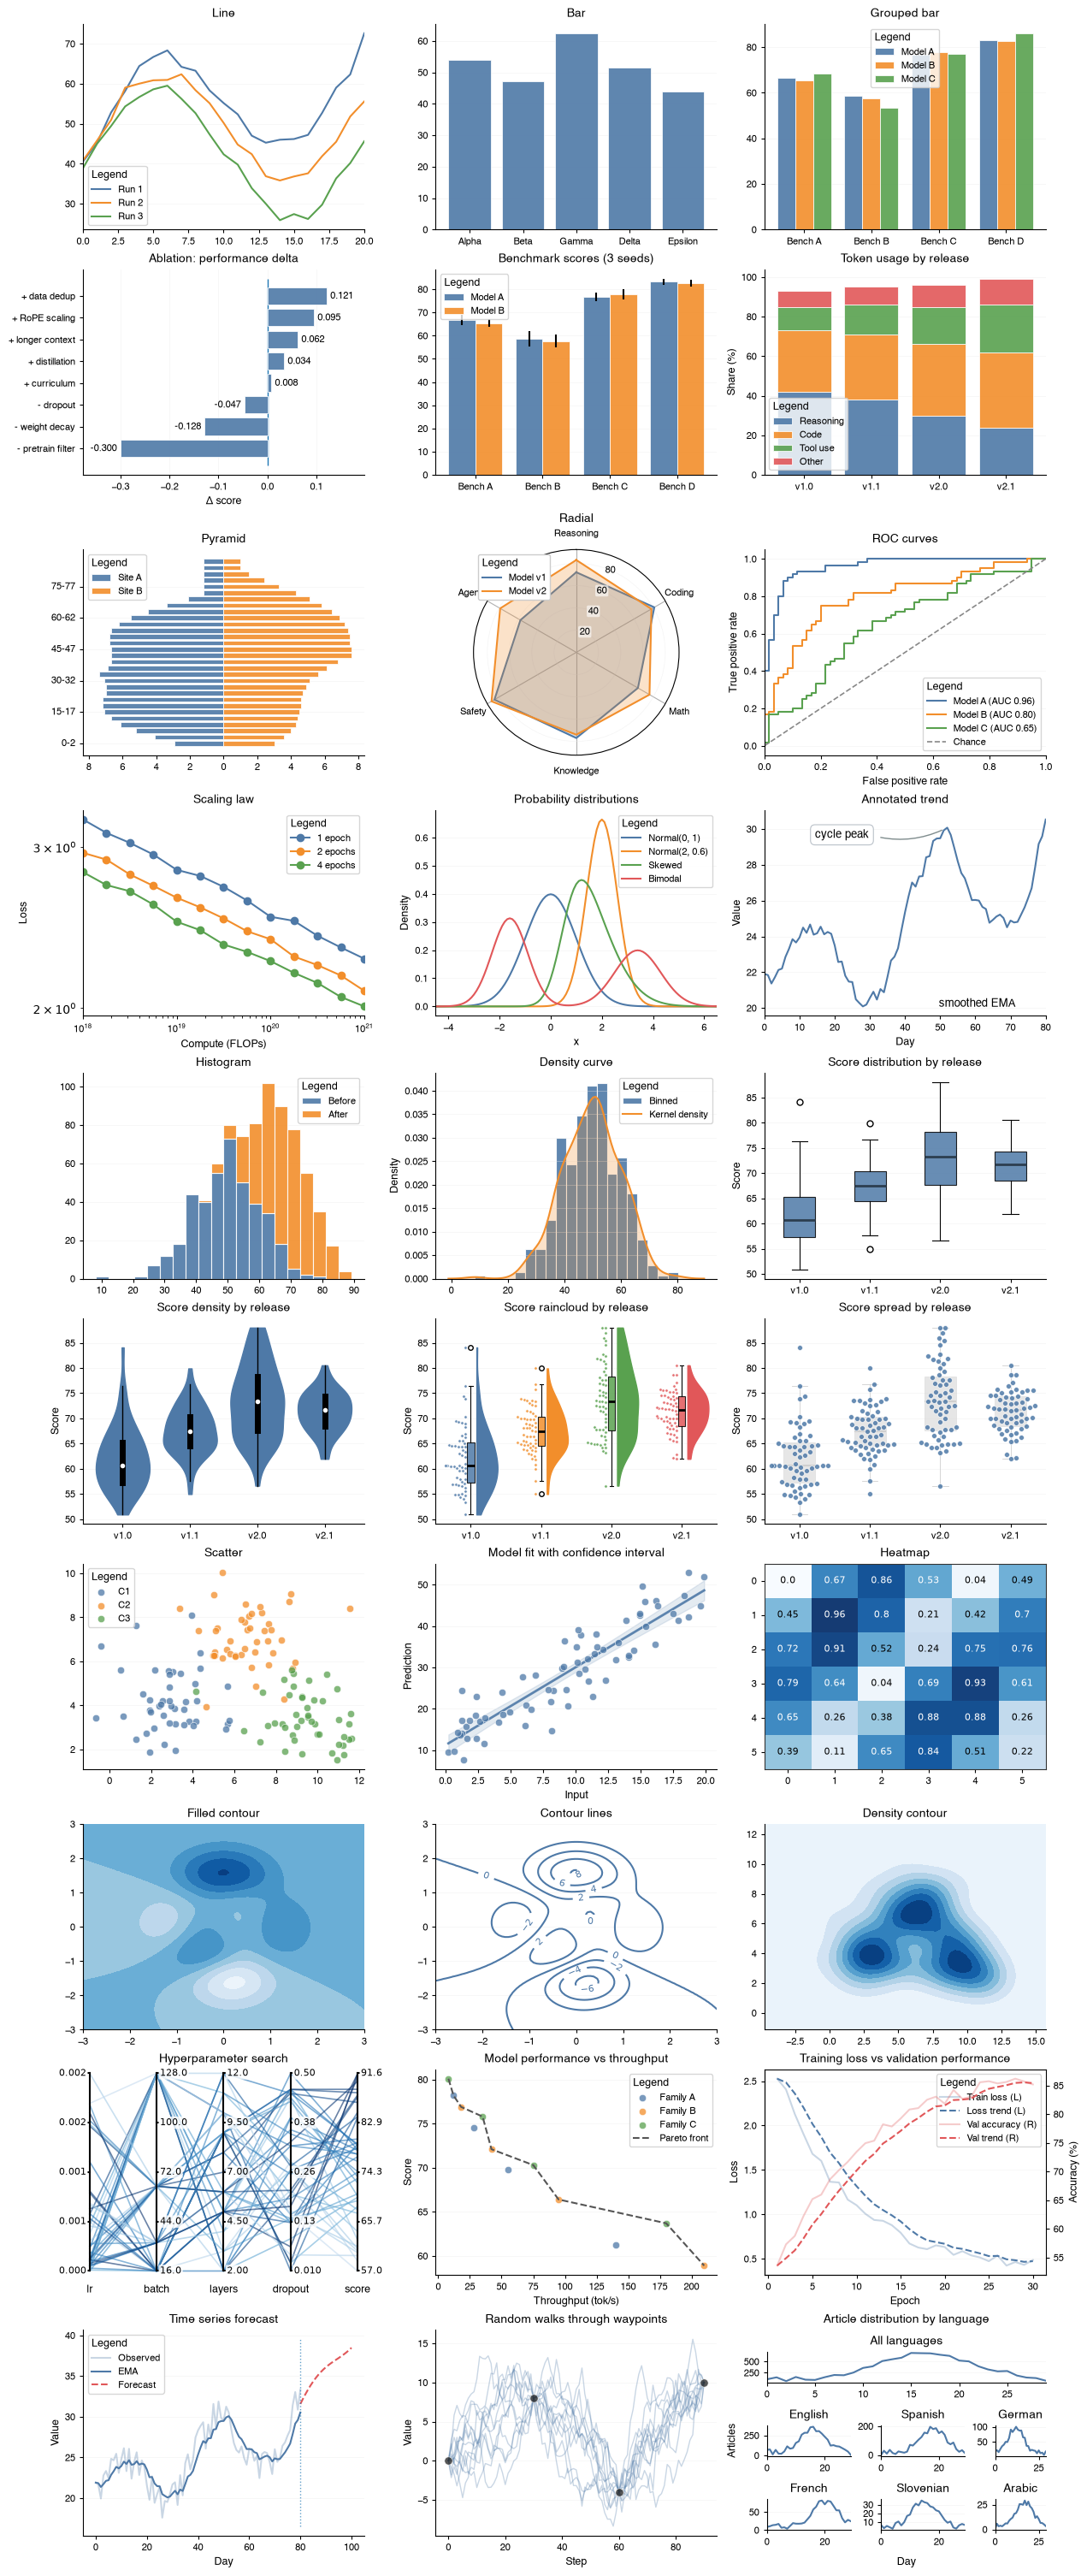

In [4]:
grid = render_gallery(THEME.DEFAULT, pair=("#4E79A7", "#E15759"))
grid.show()

## Greyscale

Monochrome and print-friendly, with the same open spines and muted grid treatment.

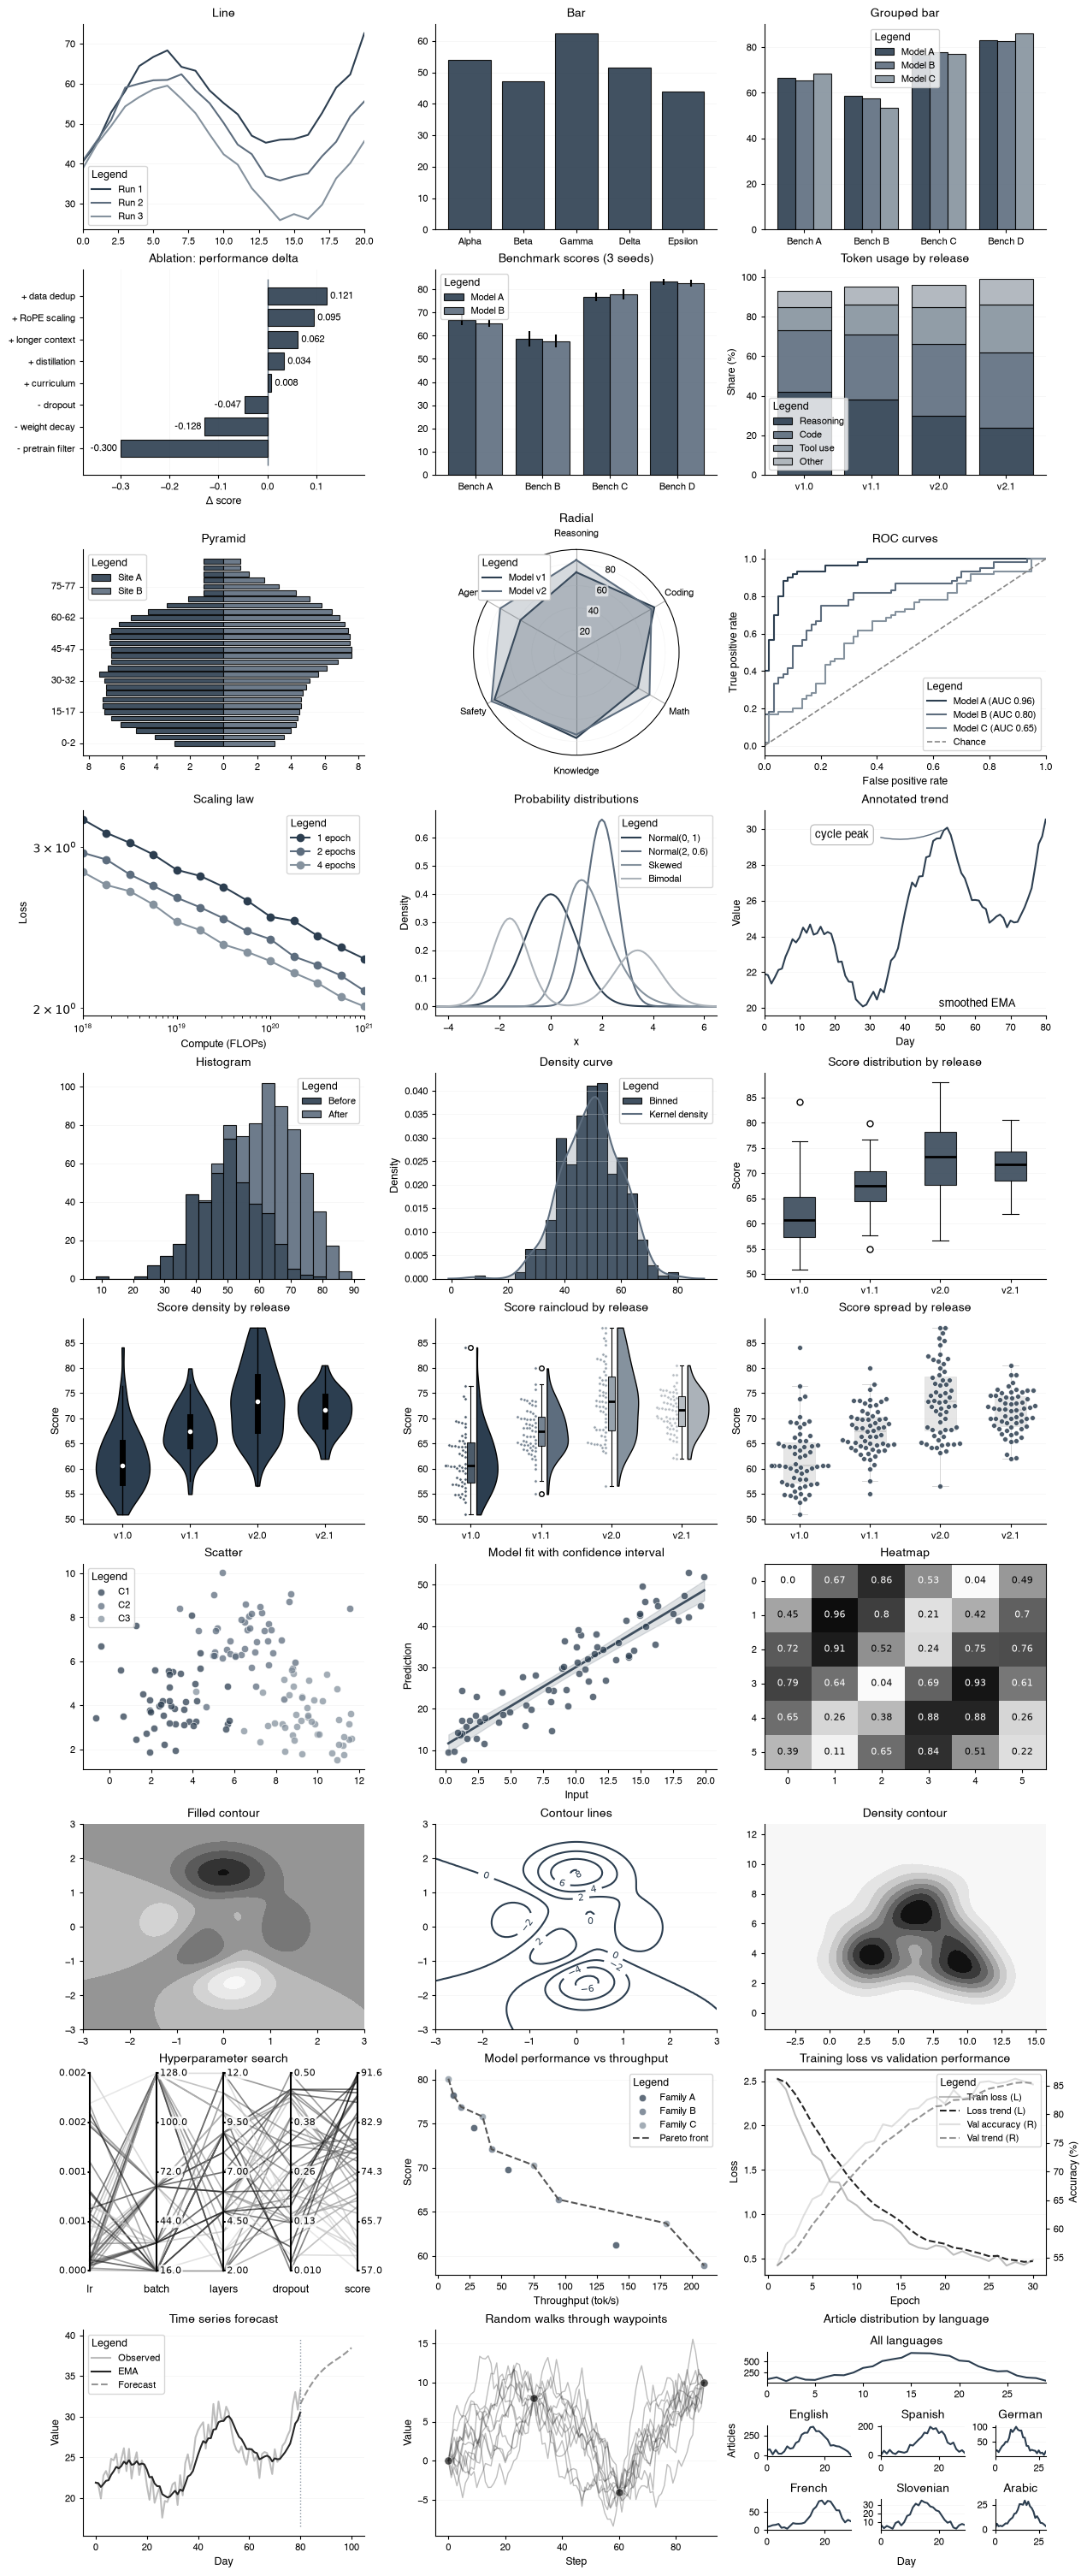

In [5]:
grid = render_gallery(THEME.GREYSCALE, pair=("#252525", "#969696"))
grid.show()

## Ink

The diversified YlGnBu palette (`COLORS.PaperYlGnBu`) with navy ink edges, print-ready.

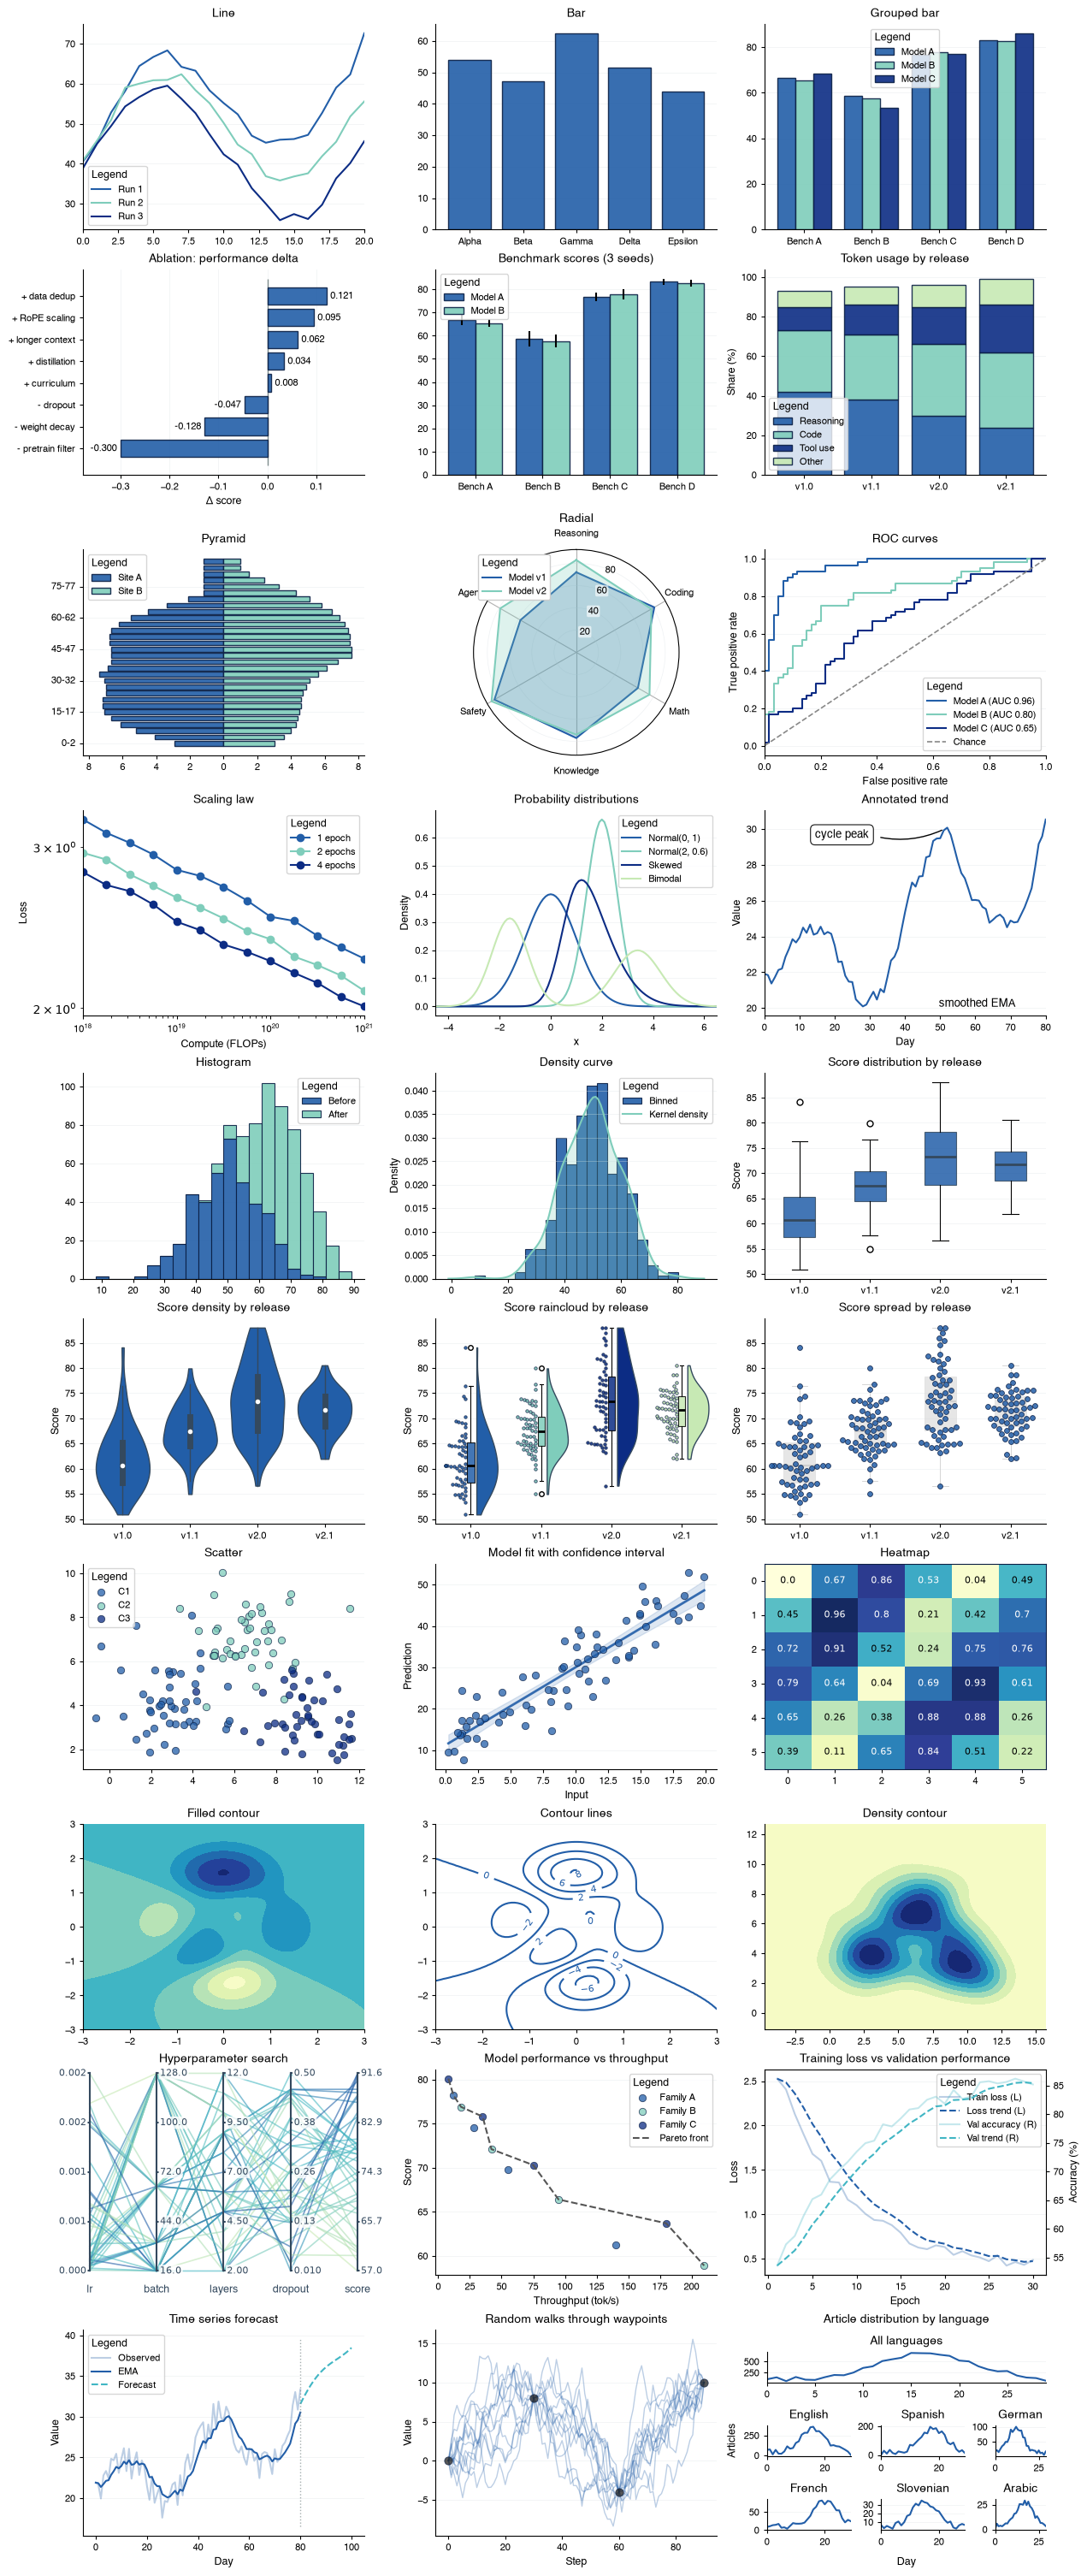

In [6]:
grid = render_gallery(THEME.INK, pair=("#225EA8", "#41B6C4"))
grid.show()

## Minimal

Accent blue with deep grays, no spines or tick marks, flat bars — and bar value labels on by default.

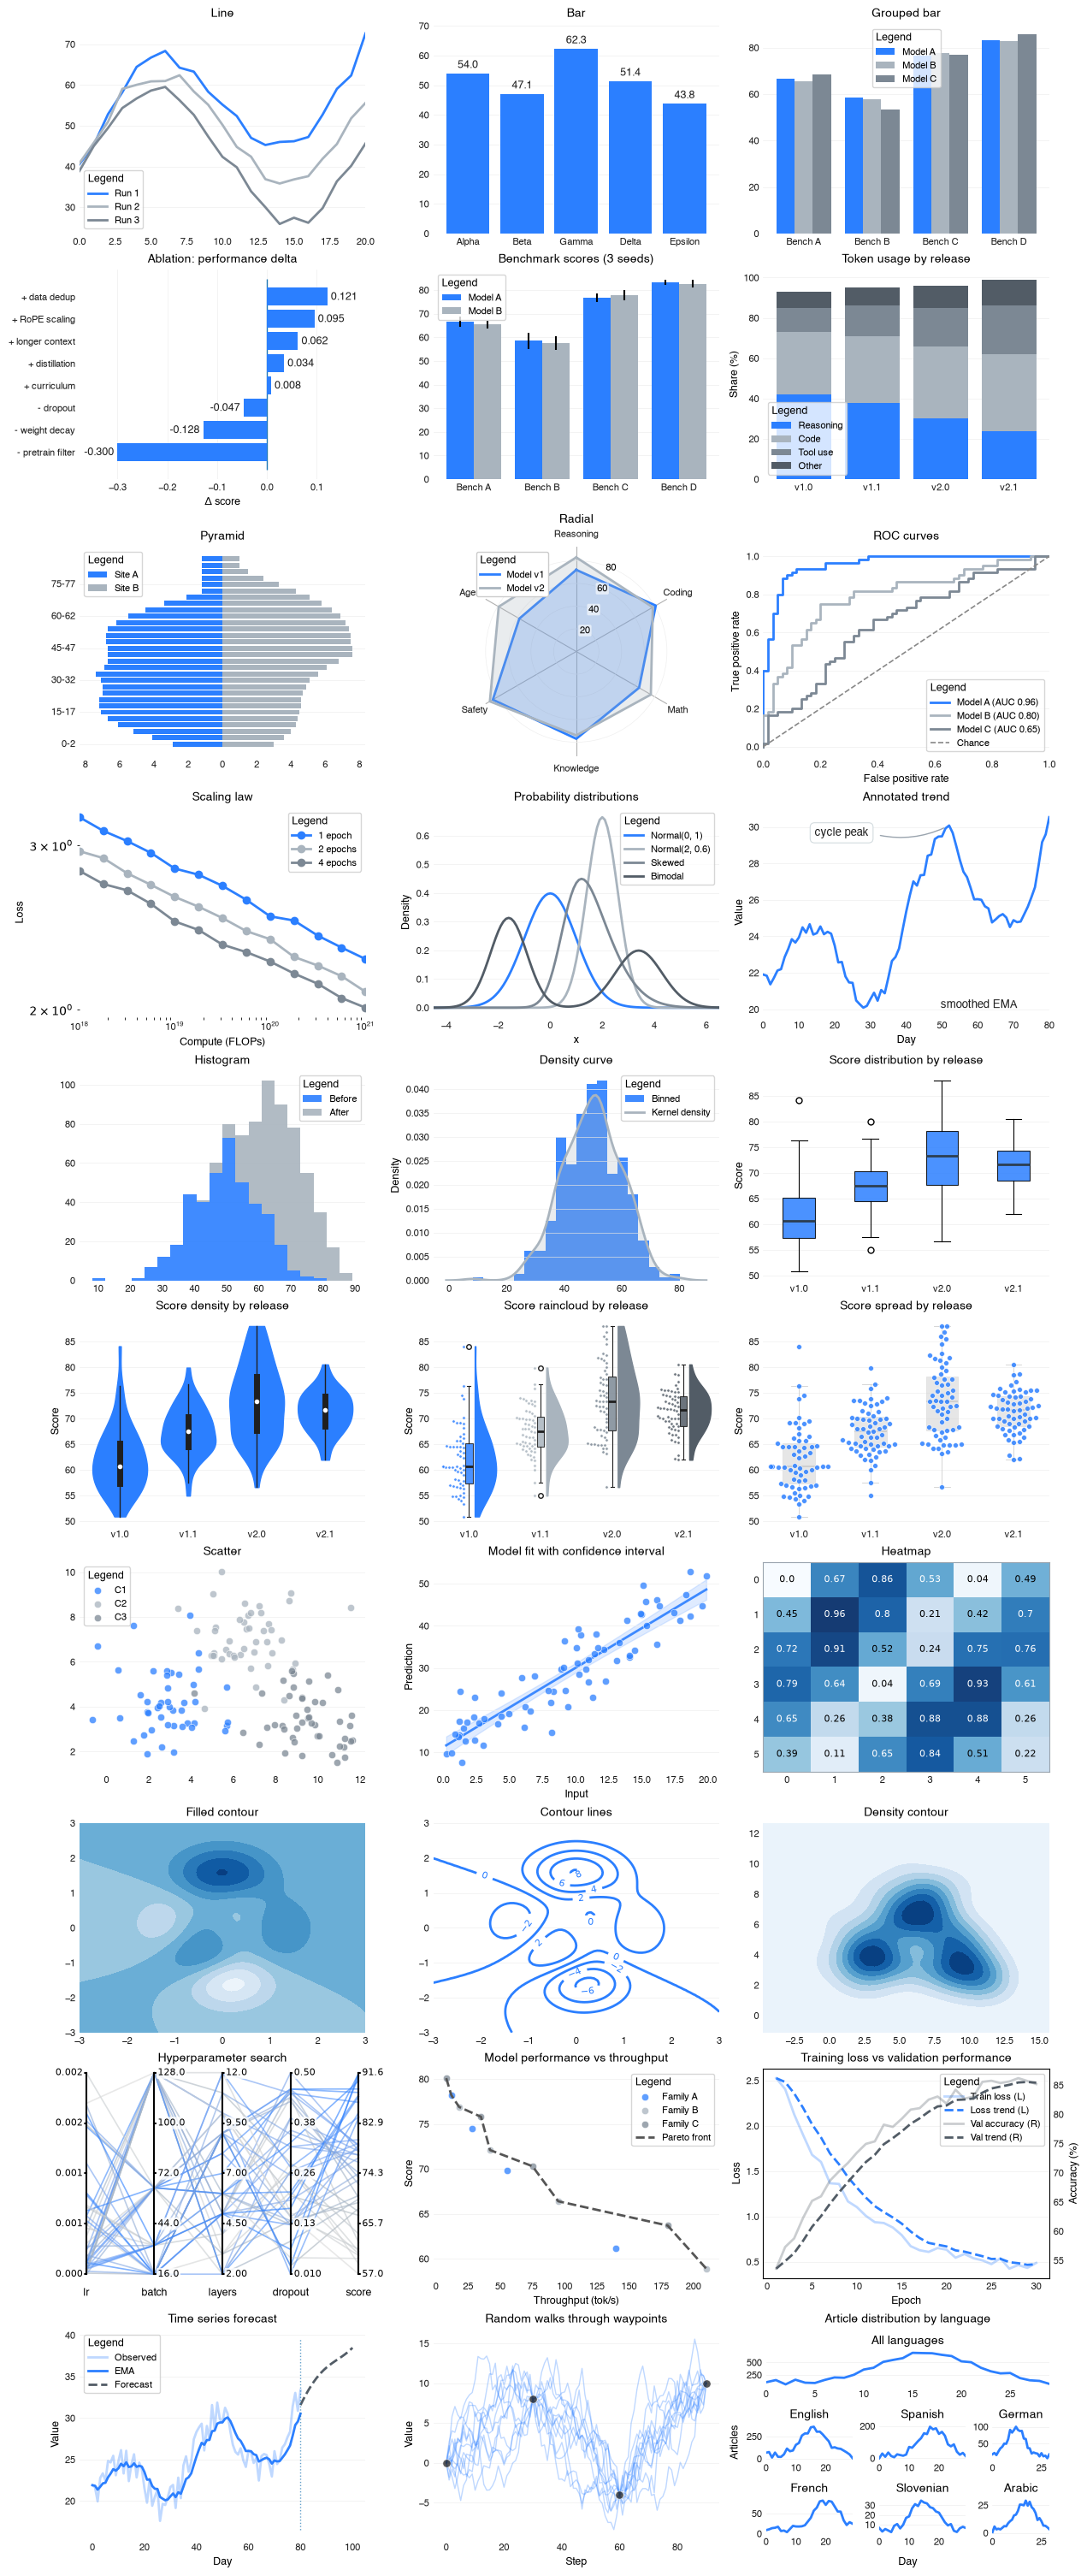

In [7]:
grid = render_gallery(THEME.MINIMAL, pair=("#2B7FFF", "#525C66"))
grid.show()

## Material

The Google palette with a bottom spine only and a light solid grid; value labels default to on.

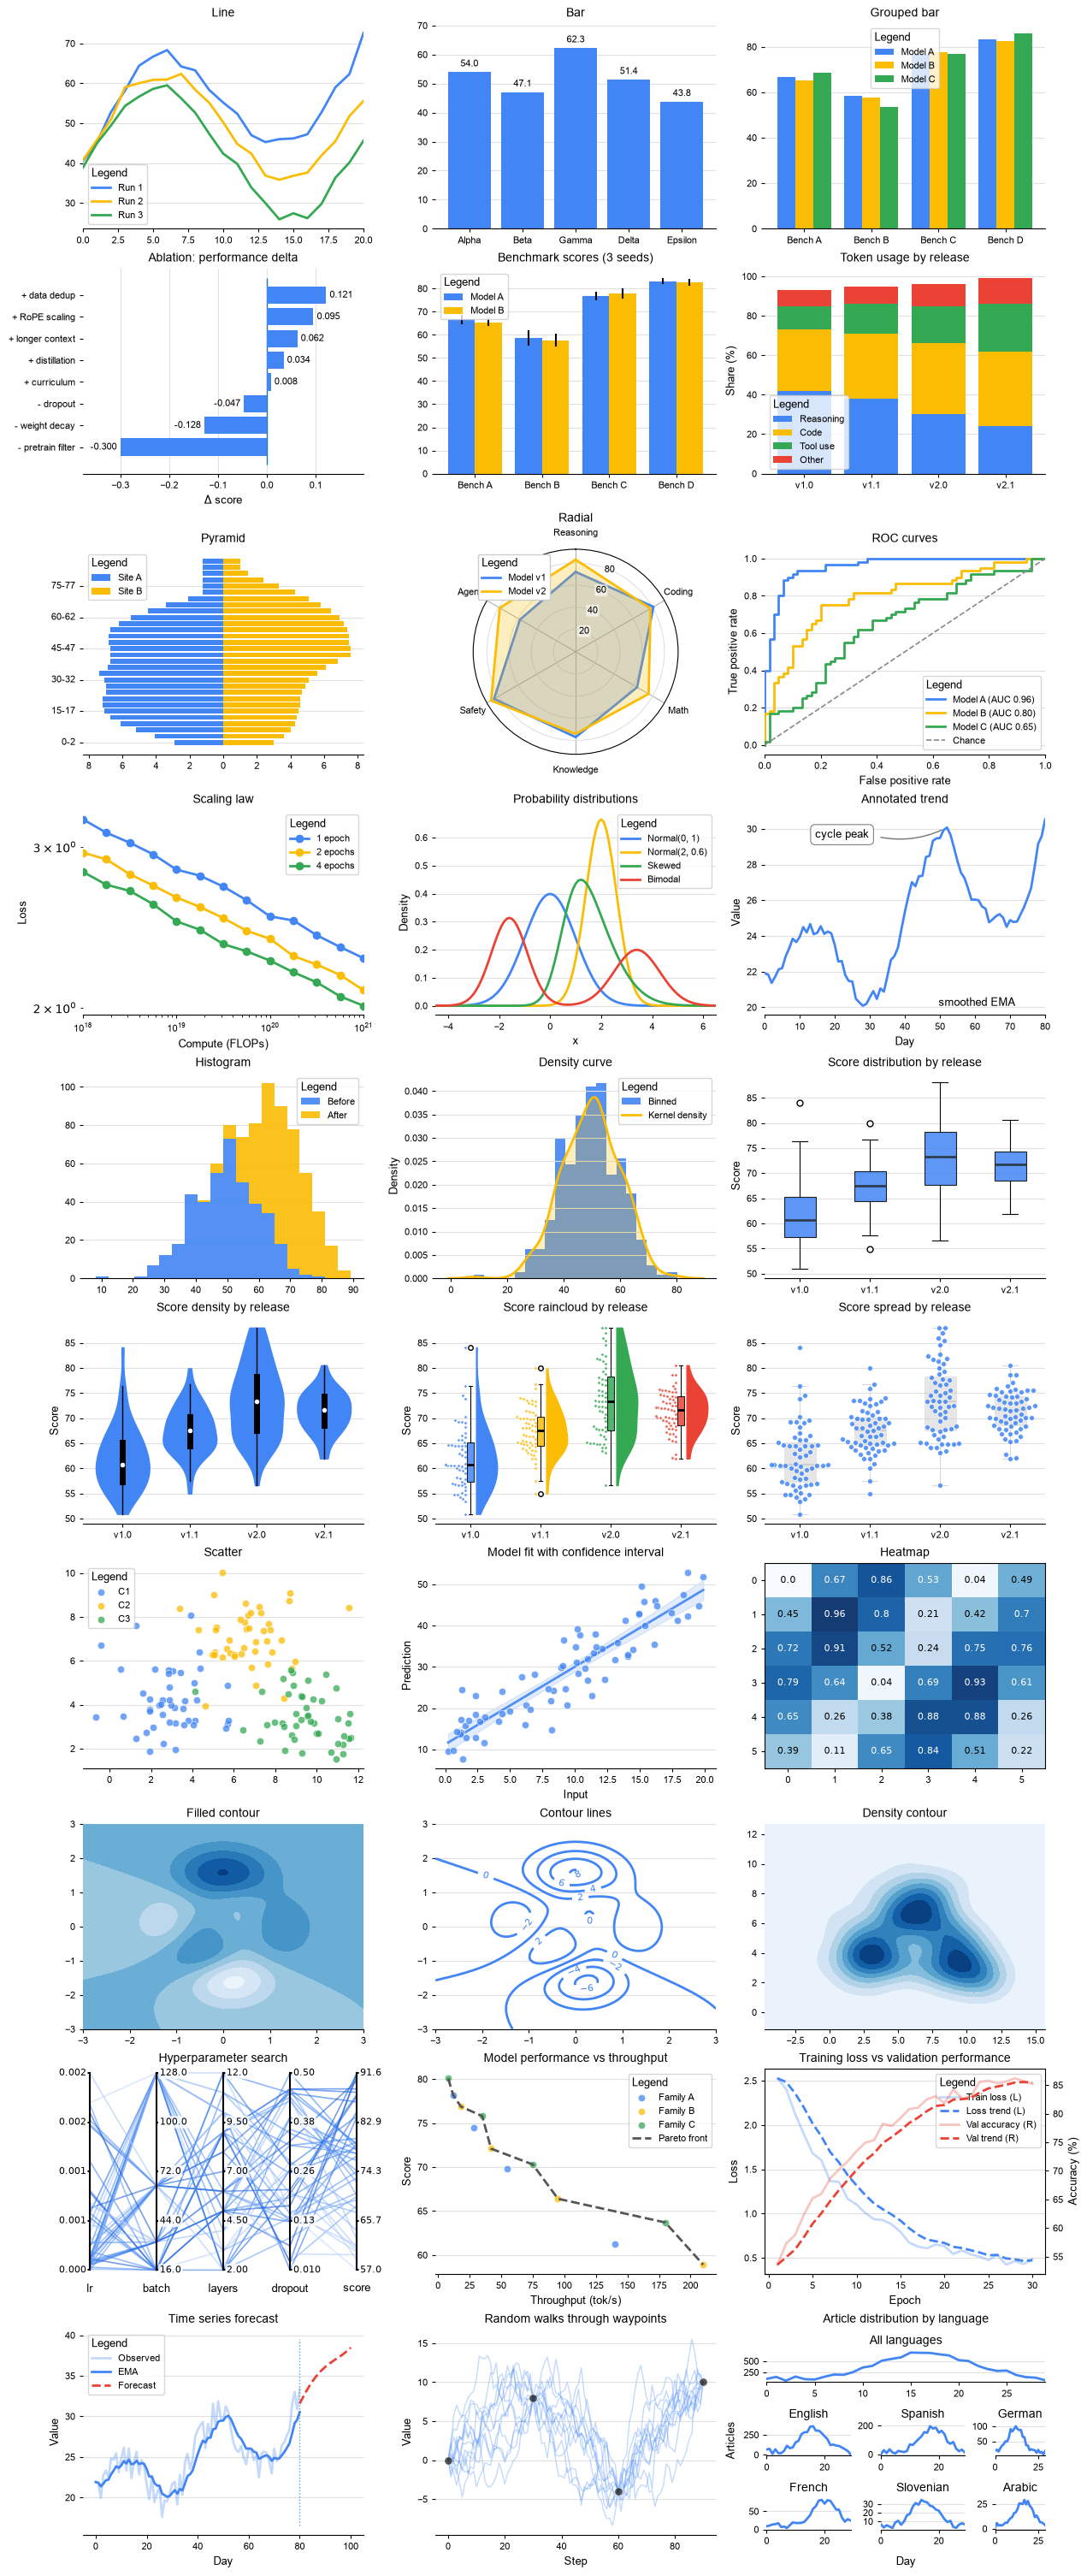

In [8]:
grid = render_gallery(THEME.MATERIAL, pair=("#4285F4", "#EA4335"))
grid.show()

## Hatch

Black edges, dotted grid — and the hatch cycle (`""`, `"//"`, `".."`) applied per bar series, so grouped bars stay distinguishable in black-and-white print.

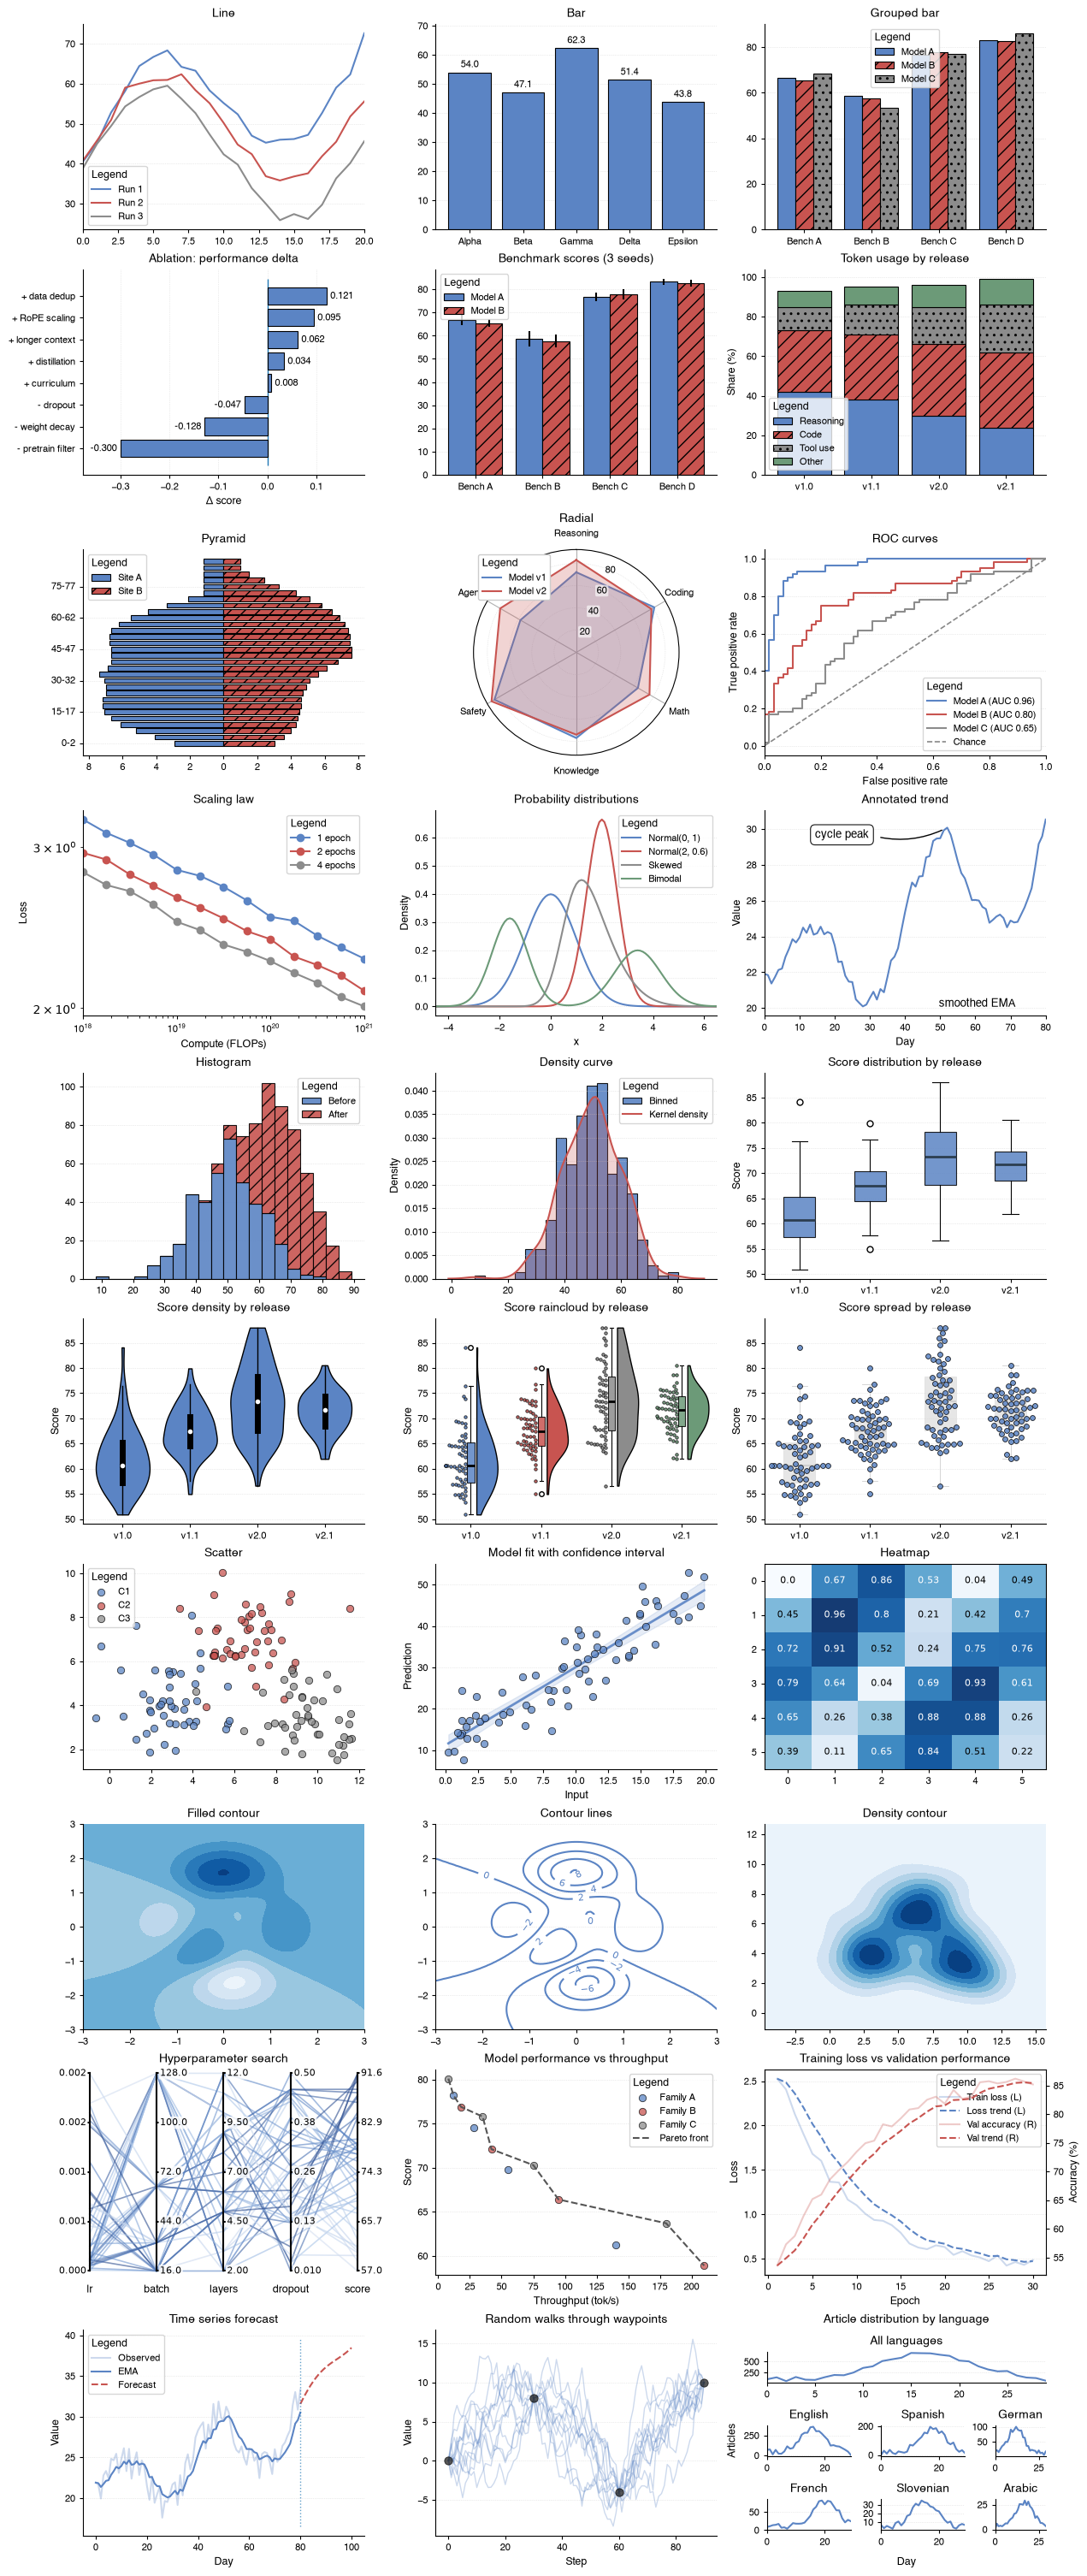

In [9]:
grid = render_gallery(THEME.HATCH, pair=("#5B84C4", "#C85450"))
grid.show()

---

Applying a theme replaces the whole global configuration, so remember to call
`config.set_theme(...)` (or `config.reset_config()`) before building the charts
it should style. See the [themes how-to](../themes/) for customizing themes
attribute by attribute.

In [10]:
config.reset_config()